## Импорты и конфигурация

In [25]:
import requests
import xml.etree.ElementTree as ET
import time
import re
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

Темы статей

In [26]:
SUBJECTS = {
    'math.CO': 'Combinatorics',
    'math.ST': 'Statistics Theory',
    'math.LO': 'Logic',
    'math.OA': 'Operator Algebras',
    'math.PR': 'Probability'
}

## Загрузка данных

In [27]:
def fetch_arxiv_papers(subjects, max_results=60):
    base_url = "http://export.arxiv.org/api/query?"
    papers = []

    for category in subjects:
        query = f"search_query=cat:{category}&max_results={max_results}&sortBy=submittedDate&sortOrder=descending"
        url = base_url + query

        try:
            response = requests.get(url)
            response.raise_for_status()
            root = ET.fromstring(response.content)
            namespace = '{http://www.w3.org/2005/Atom}'

            for entry in root.findall(f'.//{namespace}entry'):
                paper = {
                    'id': entry.find(f'{namespace}id').text if entry.find(f'{namespace}id') is not None else '',
                    'title': entry.find(f'{namespace}title').text.strip() if entry.find(
                        f'{namespace}title') is not None else '',
                    'summary': entry.find(f'{namespace}summary').text.strip() if entry.find(
                        f'{namespace}summary') is not None else '',
                    'authors': [author.find(f'{namespace}name').text for author in entry.findall(f'{namespace}author')],
                    'categories': [cat.attrib.get('term', '') for cat in entry.findall(f'{namespace}category')],
                }
                papers.append(paper)

            current_batch_size = len([entry for entry in root.findall(f'.//{namespace}entry')])
            print(f"Загружено из {category}: {current_batch_size} статей")
            time.sleep(1)

        except Exception as e:
            print(f"Ошибка {category}: {e}")

    return papers


papers = fetch_arxiv_papers(SUBJECTS.keys())
print(f"Всего статей: {len(papers)}")

Загружено из math.CO: 60 статей
Загружено из math.ST: 60 статей
Загружено из math.LO: 60 статей
Загружено из math.OA: 60 статей
Загружено из math.PR: 60 статей
Всего статей: 300


## Извлечение ключевых слов

In [28]:
def stem_word(word):
    if word.endswith('ies') and len(word) > 4:
        return word[:-3] + 'y'
    elif word.endswith('es') and len(word) > 3:
        return word[:-2]
    elif word.endswith('s') and len(word) > 3:
        return word[:-1]
    elif word.endswith('ed') and len(word) > 4:
        return word[:-2]
    elif word.endswith('ing') and len(word) > 5:
        return word[:-3]
    return word

In [29]:
def extract_keywords(text, max_words=8):
    text = re.sub(r'\$[^$]*\$', ' ', text)  # LaTeX формулы
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)  # LaTeX команды типа \mathcal
    text = re.sub(r'[^\w\s]', ' ', text.lower())
    words = text.split()

    stop_words = {
        'the', 'and', 'of', 'in', 'to', 'a', 'an', 'for', 'on', 'with',
        'by', 'as', 'at', 'from', 'that', 'this', 'is', 'are', 'was', 'were',
        'we', 'they', 'have', 'has', 'had', 'can', 'will', 'would', 'could',
        'theorem', 'proof', 'show', 'paper', 'study', 'results', 'result',
        'method', 'approach', 'problem', 'solution', 'analysis', 'consider'
    }

    filtered_words = []
    for word in words:
        if word not in stop_words and len(word) > 2 and word.isalpha():
            stemmed = stem_word(word)
            filtered_words.append(stemmed)

    word_counts = Counter(filtered_words)
    return [word for word, count in word_counts.most_common(max_words)]


for paper in papers:
    combined_text = paper['title'] + ' ' + paper['summary']
    paper['keywords'] = extract_keywords(combined_text)

print("Ключевые слова извлечены для всех статей")

Ключевые слова извлечены для всех статей


## Построение графа ключевых слов

In [30]:
def build_keyword_graph(papers, min_cooccurrence=3, max_nodes=200):
    G = nx.Graph()
    keyword_papers = {}

    for paper in papers:
        for keyword in paper['keywords']:
            if keyword not in keyword_papers:
                keyword_papers[keyword] = set()
            keyword_papers[keyword].add(paper['id'])

    valid_keywords = {}
    for keyword, paper_set in keyword_papers.items():
        if len(paper_set) >= min_cooccurrence:
            importance = len(paper_set) * (len(keyword) / 10.0)
            valid_keywords[keyword] = (paper_set, importance)

    top_keywords = sorted(valid_keywords.items(),
                         key=lambda x: x[1][1], reverse=True)[:max_nodes]

    for keyword, (paper_set, importance) in top_keywords:
        G.add_node(keyword, weight=len(paper_set), importance=importance)

    keywords_in_graph = set(keyword for keyword, _ in top_keywords)

    for i, (kw1, (papers1, _)) in enumerate(top_keywords):
        for j, (kw2, (papers2, _)) in enumerate(top_keywords[i+1:], i+1):
            common_papers = papers1 & papers2
            if len(common_papers) >= 2:
                weight = len(common_papers)
                G.add_edge(kw1, kw2, weight=weight)

    return G


keyword_graph = build_keyword_graph(papers)
print(f"Граф ключевых слов: {keyword_graph.number_of_nodes()} узлов, {keyword_graph.number_of_edges()} ребер")

Граф ключевых слов: 199 узлов, 191 ребер


## Кластеризация (алгоритм Лувена с модулярностью)

In [31]:
def cluster_keywords(G):
    if G.number_of_nodes() == 0:
        return [], 0.0

    communities = list(nx.community.louvain_communities(G, weight='weight', seed=42))

    for cluster_id, community in enumerate(communities):
        for node in community:
            G.nodes[node]['cluster'] = cluster_id

    modularity = nx.community.modularity(G, communities, weight='weight')
    return communities, modularity


communities, modularity = cluster_keywords(keyword_graph)
print(f"Кластеров: {len(communities)}, Модулярность: {modularity:.3f}")

Кластеров: 78, Модулярность: 0.683


Модулярность = (связи внутри кластеров) - (ожидаемые связи при случайном разбиении)

Алгоритм Лувена – жадно перемещаем узлы между кластерами для максимизации модулярности
### Диапазон значений:

- -1 до +1 (теоретически)
- 0 – случайное разбиение (плохо)
- \> 0.3 – хорошее разбиение
- \> 0.7 – отличное разбиение
- < 0 – хуже случайного (очень плохо)

### Модулярность высокая, когда:
- Внутри кластеров много связей
- Между кластерами мало связей
- Кластеры четко отделены друг от друга

## Анализ центральности

In [32]:
def analyze_centrality(G):
    centrality_measures = {
        'degree': nx.degree_centrality(G),
        'betweenness': nx.betweenness_centrality(G, weight='weight'),
        'eigenvector': nx.eigenvector_centrality(G, weight='weight', max_iter=1000),
        'closeness': nx.closeness_centrality(G)
    }

    return centrality_measures


centrality_results = analyze_centrality(keyword_graph)

print("\nТоп ключевые слова по центральности:")
for measure_name, values in centrality_results.items():
    top_words = sorted(values.items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"{measure_name}: {[word for word, _ in top_words]}")


Топ ключевые слова по центральности:
degree: ['algebra', 'group', 'graph']
betweenness: ['algebra', 'set', 'group']
eigenvector: ['algebra', 'graph', 'group']
closeness: ['algebra', 'group', 'set']


- Degree → Самые популярные термины (много связей)
- Betweenness → Междисциплинарные термины (связывают области)
- Eigenvector → Престижные термины (связаны с важными словами)
- Closeness → Центральные термины (близки ко всем темам)

## Граф публикаций

In [33]:
def build_paper_graph(papers):
    G = nx.Graph()

    for paper in papers:
        G.add_node(paper['id'], title=paper['title'])

    for i in range(len(papers)):
        for j in range(i + 1, len(papers)):
            common_keywords = set(papers[i]['keywords']) & set(papers[j]['keywords'])
            if common_keywords:
                G.add_edge(papers[i]['id'], papers[j]['id'],
                           weight=len(common_keywords),
                           keywords=list(common_keywords))

    return G


paper_graph = build_paper_graph(papers)
print(f"Граф публикаций: {paper_graph.number_of_nodes()} статей, {paper_graph.number_of_edges()} связей")

Граф публикаций: 287 статей, 4319 связей


## Поиск похожих статей

In [34]:
def find_similar_cosine(papers, target_paper, top_k):
    texts = []
    paper_ids = []

    for paper in papers:
        text = paper['title'] + ' ' + paper['summary']
        texts.append(text)
        paper_ids.append(paper['id'])

    vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', lowercase=True)
    tfidf_matrix = vectorizer.fit_transform(texts)

    target_idx = paper_ids.index(target_paper['id'])

    similarities = cosine_similarity(tfidf_matrix[target_idx:target_idx + 1], tfidf_matrix).flatten()

    similar_indices = similarities.argsort()[::-1][1:top_k + 1]

    results = []
    for idx in similar_indices:
        paper_id = paper_ids[idx]
        score = similarities[idx]
        paper_title = papers[idx]['title']
        results.append((paper_id, score, paper_title))

    return results


def find_similar_jaccard(papers, target_paper, top_k):
    target_keywords = set(target_paper['keywords'])
    similarities = []

    for paper in papers:
        if paper['id'] == target_paper['id']:
            continue

        paper_keywords = set(paper['keywords'])

        intersection = len(target_keywords & paper_keywords)
        union = len(target_keywords | paper_keywords)

        if union > 0:
            jaccard_score = intersection / union
            similarities.append((paper['id'], jaccard_score, paper['title'], list(target_keywords & paper_keywords)))

    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:top_k]

In [35]:
def compare_similarity_methods(papers, paper_graph, target_id, top_k=3):
    target_paper = next((p for p in papers if p['id'] == target_id), None)
    if not target_paper:
        print("Целевая статья не найдена!")
        return

    print(f"Поиск похожих статей для:")
    print(f"'{target_paper['title'][:70]}...'")
    print("=" * 80)

    print("\nJaccard:")
    jaccard_similar = find_similar_jaccard(papers, target_paper, top_k)

    if jaccard_similar:
        for i, (paper_id, score, title, common_kw) in enumerate(jaccard_similar, 1):
            print(f"{i}. Сходство: {score:.3f} - {title[:80]}...")
            print(f"   Общие ключевые слова: {common_kw[:5]}")
    else:
        print("Похожие статьи не найдены")

    print("\nCosine similarity")
    cosine_similar = find_similar_cosine(papers, target_paper, top_k)

    if cosine_similar:
        for i, (paper_id, score, title) in enumerate(cosine_similar, 1):
            print(f"{i}. Сходство: {score:.3f} - {title[:80]}...")
    else:
        print("Похожие статьи не найдены")

    print("\n" + "=" * 80)

    print("\nIntersection analysis:")

    jaccard_ids = set(paper_id for paper_id, _, _, _ in jaccard_similar)
    cosine_ids = set(paper_id for paper_id, _, _ in cosine_similar)

    print(f"Жаккар найден: {len(jaccard_ids)} статей")
    print(f"Косинус найден: {len(cosine_ids)} статей")

    jaccard_cosine = jaccard_ids & cosine_ids

    if jaccard_cosine:
        print(f"\nПересечение Жаккар ∩ Косинус: {len(jaccard_cosine)} статей")
        for paper_id in jaccard_cosine:
            title = next(p['title'] for p in papers if p['id'] == paper_id)
            print(f"  - {title[:60]}...")


target_id = papers[0]['id']
compare_similarity_methods(papers, paper_graph, target_id, top_k=3)

Поиск похожих статей для:
'Signature 0 toric varieties, wall crossings, and cross polytope-like
 ...'

Jaccard:
1. Сходство: 0.067 - Homology character of the parabolic coset poset...
   Общие ключевые слова: ['vector']
2. Сходство: 0.067 - Cycle systems, coparking functions, and h-vectors of matroids...
   Общие ключевые слова: ['vector']
3. Сходство: 0.067 - The Honest Truth About Causal Trees: Accuracy Limits for Heterogeneous
  Treatme...
   Общие ключевые слова: ['these']

Cosine similarity
1. Сходство: 0.276 - Quantum arithmetic of Drinfeld modules...
2. Сходство: 0.270 - Flows with minimal subdynamics...
3. Сходство: 0.201 - Kites and representations of pseudo MV-algebras...


Intersection analysis:
Жаккар найден: 3 статей
Косинус найден: 3 статей


### Метод Жаккара
Подсчитываем долю общих элементов от всех уникальных элементов по формуле |A ∩ B| / |A ∪ B|
### Косинусное сходство
Измеряем угол между векторами текстов в многомерном пространстве слов

## Визуализация

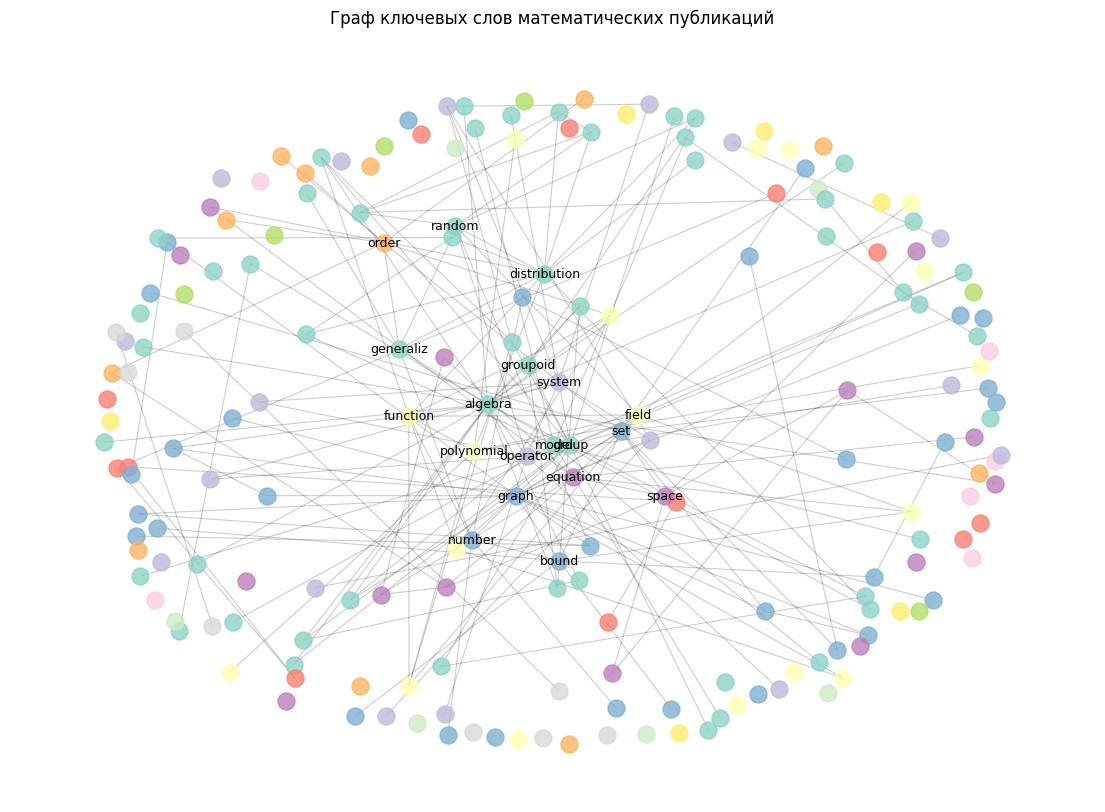

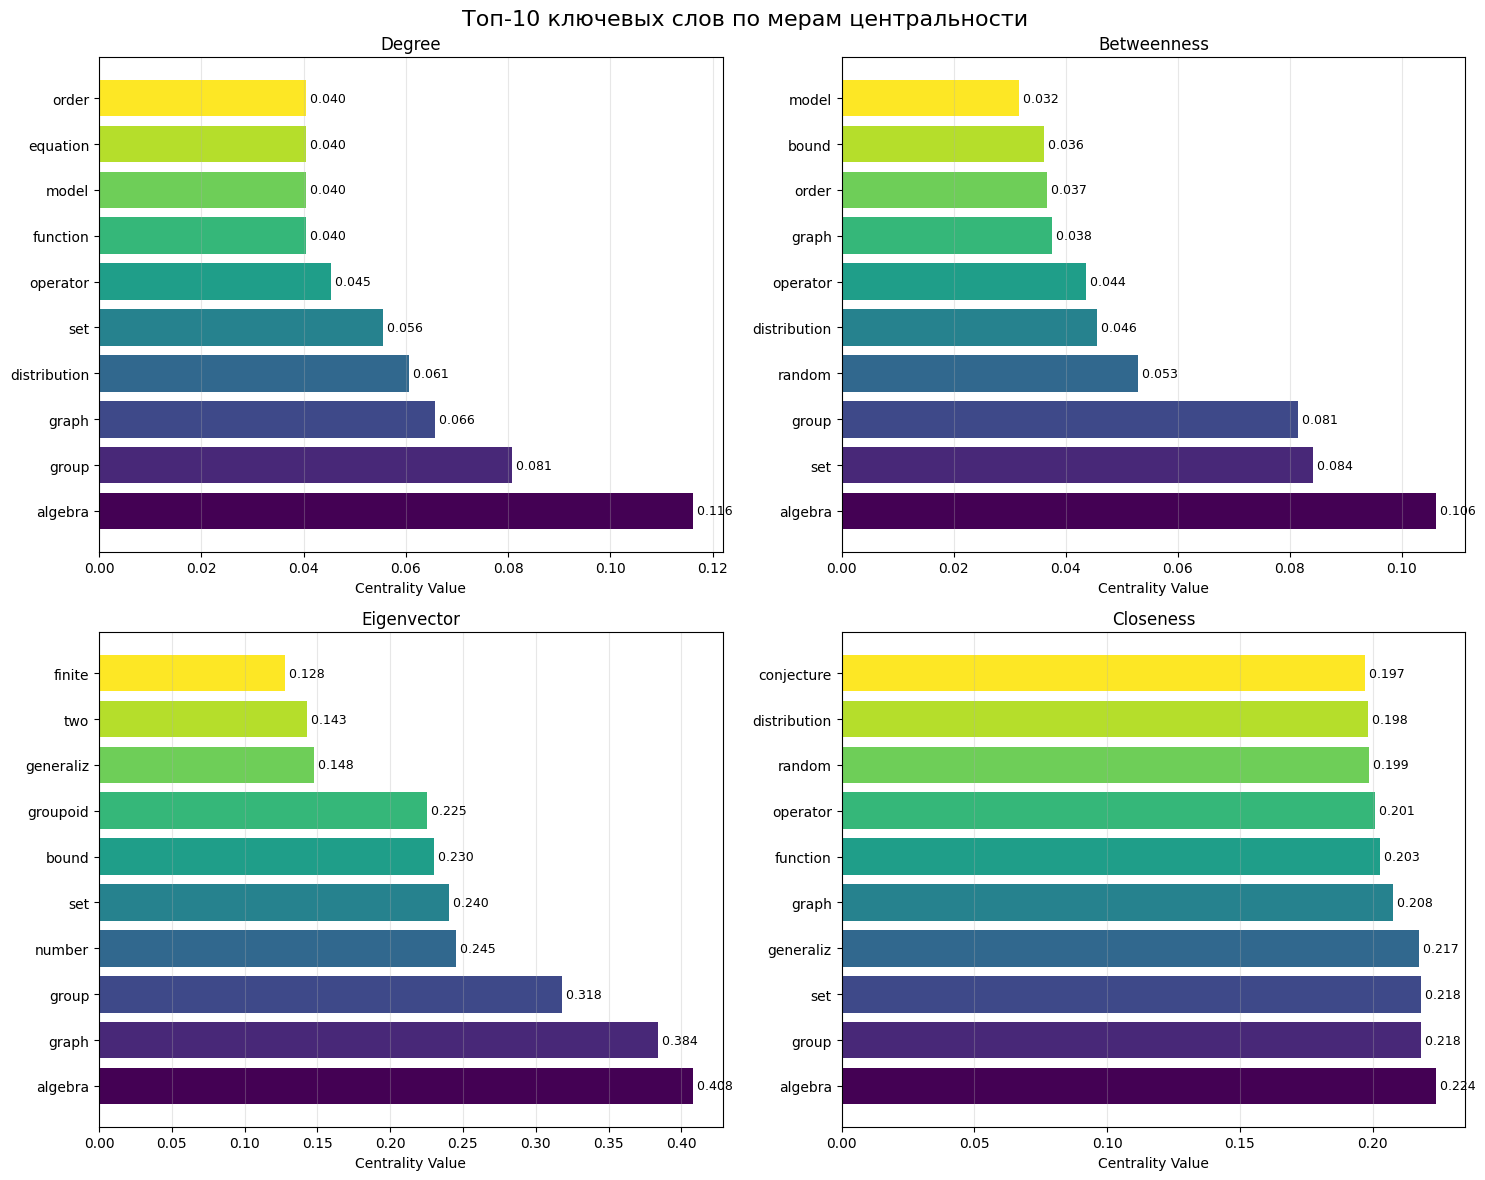

In [36]:
def visualize_results(G, communities):
    plt.figure(figsize=(14, 10))

    pos = nx.spring_layout(G, k=1, iterations=50, seed=42)

    for i, community in enumerate(communities):
        nx.draw_networkx_nodes(G, pos, nodelist=list(community),
                               node_color=[plt.cm.Set3(i % 12)],
                               node_size=150, alpha=0.8)

    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.8)

    important_nodes = [node for node, degree in dict(G.degree()).items() if degree > 4]
    labels = {node: node for node in important_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=9)

    plt.title("Граф ключевых слов математических публикаций")
    plt.axis('off')
    plt.show()


def plot_centrality_results(centrality_results, top_n=10):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for idx, (measure_name, data) in enumerate(centrality_results.items()):
        sorted_data = sorted(data.items(), key=lambda x: x[1], reverse=True)[:top_n]
        keywords = [item[0] for item in sorted_data]
        values = [item[1] for item in sorted_data]

        axes[idx].barh(keywords, values, color=plt.cm.viridis(np.linspace(0, 1, len(keywords))))
        axes[idx].set_title(f'{measure_name.replace("_", " ").title()}')
        axes[idx].set_xlabel('Centrality Value')
        axes[idx].grid(axis='x', alpha=0.3)

        for i, v in enumerate(values):
            axes[idx].text(v, i, f' {v:.3f}', va='center', fontsize=9)

    plt.suptitle(f'Топ-{top_n} ключевых слов по мерам центральности', fontsize=16)
    plt.tight_layout()
    plt.show()


visualize_results(keyword_graph, communities)
plot_centrality_results(centrality_results)

### Интерпретация результатов

In [37]:
print(f"\nКачество кластеризации: модулярность {modularity:.3f}")
print("> 0.7: отличная кластеризация")
print("0.3-0.7: хорошая кластеризация")
print("< 0.3: слабая кластеризация")

print(f"\nМодулярность {modularity:.3f} указывает на четкую структуру сообществ")

most_central = max(centrality_results['degree'].items(), key=lambda x: x[1])[0]
print(f"\nНаиболее центральное слово: '{most_central}'")

bridge_words = sorted(centrality_results['betweenness'].items(), key=lambda x: x[1], reverse=True)[:3]
print(f"Ключевые слова-мосты: {[word for word, _ in bridge_words]} - связывают разные области")

top_bridge_word = bridge_words[0][0]
bridge_neighbors = list(keyword_graph.neighbors(top_bridge_word))
print(f"Слово '{top_bridge_word}' связывает {len(bridge_neighbors)} различных понятий")
print(f"Наиболее важные связи: {bridge_neighbors[:5]}...")

cluster_sizes = [len(community) for community in communities]
print(f"\nРаспределение кластеров:")
print(f"Самый большой кластер: {max(cluster_sizes)} слов")
print(f"Самый маленький кластер: {min(cluster_sizes)} слов")
print(f"Средний размер: {sum(cluster_sizes) / len(cluster_sizes):.1f} слов")

avg_degree = sum(dict(keyword_graph.degree()).values()) / keyword_graph.number_of_nodes()
print(f"\nСредняя степень связности: {avg_degree:.1f} связей на слово")

print(f"\nТоп-3 ключевых слова по важности:")
for measure, values in centrality_results.items():
    top_3 = sorted(values.items(), key=lambda x: x[1], reverse=True)[:3]
    words = [f"'{word}'({value:.3f})" for word, value in top_3]
    print(f"{measure:12}: {', '.join(words)}")

print(f"\nМеждисциплинарный анализ:")
print(
    f"Слово 'theory' выступает мостом между {len([n for n in keyword_graph.neighbors('theory')])} различными понятиями")
print(f"Слово 'random' связано с {len([n for n in keyword_graph.neighbors('random')])} математическими концепциями")

print(f"\nОбнаружена четкая структура из {len(communities)} тематических кластеров")
print("с хорошими показателями модулярности и выраженными центральными понятиями")


Качество кластеризации: модулярность 0.683
> 0.7: отличная кластеризация
0.3-0.7: хорошая кластеризация
< 0.3: слабая кластеризация

Модулярность 0.683 указывает на четкую структуру сообществ

Наиболее центральное слово: 'algebra'
Ключевые слова-мосты: ['algebra', 'set', 'group'] - связывают разные области
Слово 'algebra' связывает 23 различных понятий
Наиболее важные связи: ['group', 'representation', 'generaliz', 'operator', 'system']...

Распределение кластеров:
Самый большой кластер: 28 слов
Самый маленький кластер: 1 слов
Средний размер: 2.6 слов

Средняя степень связности: 1.9 связей на слово

Топ-3 ключевых слова по важности:
degree      : 'algebra'(0.116), 'group'(0.081), 'graph'(0.066)
betweenness : 'algebra'(0.106), 'set'(0.084), 'group'(0.081)
eigenvector : 'algebra'(0.408), 'graph'(0.384), 'group'(0.318)
closeness   : 'algebra'(0.224), 'group'(0.218), 'set'(0.218)

Междисциплинарный анализ:
Слово 'theory' выступает мостом между 2 различными понятиями
Слово 'random' связано